In [1]:
import furuta_systems
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import furuta_params
import furuta_trajectory_gen
from IPython.display import display, Math

params_auslegung = furuta_params.FurutaParams()
params_auslegung.mu_H1 = 0.0
params_auslegung.mu_H2 = 0.0
tau_max = params_auslegung.tau_max
operating_point = (0,0,0,0,0)

**3.8 Geben Sie zunächst allgemein die Ruhelagen des Systems an.**

In [2]:
display(Math(r"\tau = 0"))

display(Math(r"m_2 \, l_2 \, g \, \sin(\theta_2) = 0"))

display(Math(r"\theta_2 = 0 \;\text{oder}\; \theta_2 = \pi"))

display(Math(r"\theta_1 \;\text{ist beliebig}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**3.9 Für den Steuerungsentwurf linearisieren Sie das nichtlineare Modell des FurutaPendels um die stabile Ruhelage**

**a) Berechnen Sie die Systemmatrix A und den Eingangsvektor b mit den in Tab. 1
gegebenen Parametern.**

In [3]:
#Arbeitspunkt 0, 0, 0, 0, 0
A_lin, b_lin = furuta_systems.get_linear_furuta(params_auslegung, operating_point)
A_lin

array([[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00, -1.75161710e+01,  1.07509938e+00,
         4.43968359e-04],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00],
       [ 0.00000000e+00,  1.69687907e+01, -6.23540025e+01,
        -2.57494374e-02]])

In [4]:
b_lin

array([[  0.        ],
       [ 34.40615006],
       [  0.        ],
       [-33.33095788]])

**b) Überprüfen Sie die Steuerbarkeit des linearisierten Modells.**

In [5]:
# SymPy -> NumPy
A_np = A_lin
b_np = b_lin

n = A_np.shape[0]

# Steuerbarkeitsmatrix S = [B, AB, A^2B, ...]
S_blocks = [np.linalg.matrix_power(A_np, k) @ b_np for k in range(n)] #liste von spalten vektoren
S_np = np.hstack(S_blocks) #spaletenvektoren werden zu matrix zusammen gefügt

rankS = np.linalg.matrix_rank(S_np)  # nutzt intern Toleranz (SVD-basiert)

print("S shape:", S_np.shape)
print("rank(S):", rankS)
print("voll steuerbar?", rankS == n)

S shape: (4, 4)
rank(S): 4
voll steuerbar? True


**c) Berechnen Sie die Eigenwerte der Systemmatrix.**

In [6]:
np.linalg.eig(A_np)

EigResult(eigenvalues=array([  0.        +0.j        , -17.46681993+0.j        ,
        -0.03755025+7.84119401j,  -0.03755025-7.84119401j]), eigenvectors=array([[ 1.00000000e+00+0.j        , -4.44670392e-02+0.j        ,
        -8.23695775e-04+0.00037581j, -8.23695775e-04-0.00037581j],
       [ 0.00000000e+00+0.j        ,  7.76697767e-01+0.j        ,
        -2.91590107e-03-0.00647287j, -2.91590107e-03+0.00647287j],
       [ 0.00000000e+00+0.j        ,  3.59123592e-02+0.j        ,
        -6.05792834e-04-0.12650086j, -6.05792834e-04+0.12650086j],
       [ 0.00000000e+00+0.j        , -6.27274712e-01+0.j        ,
         9.91940495e-01+0.j        ,  9.91940495e-01-0.j        ]]))

In [7]:
# Symbol für lambda
lam = sp.symbols('λ')

# Charakteristisches Polynom
char_poly = np.poly(A_np)
char_poly

array([1.00000000e+00, 1.75419204e+01, 6.27975005e+01, 1.07396023e+03,
       0.00000000e+00])

**d) Überführen Sie das linearisierte System in Regelungsnormalform (RNF) und führen 
Sie einen flachen Ausgang ein.**


In [8]:
A_RNF, Q = furuta_systems.get_RNF_furuta(params_auslegung, operating_point)
b_RNF = Q @ b_np
A_RNF


array([[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00],
       [ 0.00000000e+00, -1.07396023e+03, -6.27975005e+01,
        -1.75419204e+01]])

**e) Erarbeiten Sie auf Basis der RNF eine Steuerung, die zur Überführung zwischen 
stationären Regimen innerhalb eines vorgegebenes Zeitintervall geeignet ist.**

In [9]:
# Symbole
n, k = sp.symbols('n k', integer=True, nonnegative=True)
tau = sp.symbols('tau', nonzero=True)

# Formel als SymPy-Ausdruck (allgemein)
phi = sp.factorial(2*n + 1) / sp.factorial(n)**2 * sp.summation(
    sp.binomial(n, k) * (-1)**k * tau**(n + k + 1) / (n + k + 1),
    (k, 0, n)
)

# Beispiel: n = 4
phi4 = sp.simplify(phi.subs(n, 4))
phi4

Piecewise((126*tau**5*hyper((-4, 5), (6,), tau), (tau >= -1) & (tau <= 1)), (tau**5*(70*tau**4 - 315*tau**3 + 540*tau**2 - 420*tau + 126), True))

Trajektorie für den Flachen Ausgang bestimmen:

**3.10 Implementieren Sie die erarbeitete Steuerung und simulieren Sie diese mit dem 
nichtlinearen Modell für eine Überführung des Zustandes von der stabilen Ruhelage**


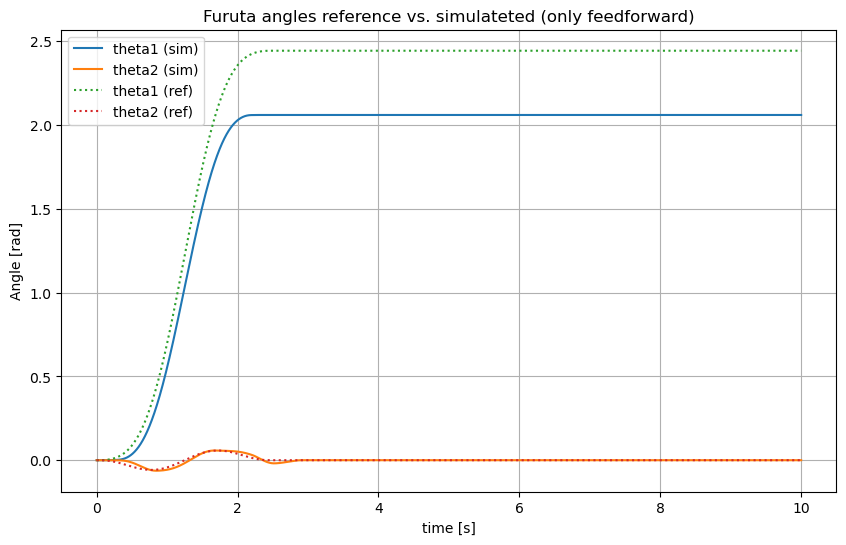

In [10]:
# b0 für Ausgang gleich Theta1 finden
cT = np.array([[1, 0, 0, 0]])
b0, b1, b2, b3 = furuta_systems.get_b_coefficients_furuta(cT, params_auslegung, operating_point)

y0 = 0.0
yT = (140.0/360.0) * 2 * np.pi
eta0 = y0/b0
etaT = yT/b0
t0 = 0
t1 = 2.5

u_ref, x_ref = furuta_trajectory_gen.generate_trajectorys(eta0, etaT, t0, t1, params_auslegung, operating_point)

params_sim = furuta_params.FurutaParams()
haft_reibung = True
if not haft_reibung:
    params_sim.mu_H1 = 0.0
    params_sim.mu_H2 = 0.0

non_linear_furuta_system = furuta_systems.get_non_linear_furuta_system(params_sim)

x0 = [0.0, 0.0, 0.0, 0.0]
t_sim = np.linspace(0.0, 10.0, 10000)

def simulation_system_feedforward(t, x):
    u = u_ref(t)
    return non_linear_furuta_system(t, x, u)

sol = solve_ivp(
    simulation_system_feedforward,
    (float(t_sim[0]), float(t_sim[-1])),
    x0,
    t_eval=t_sim,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-3,
)

#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("Furuta angles reference vs. simulateted (only feedforward)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

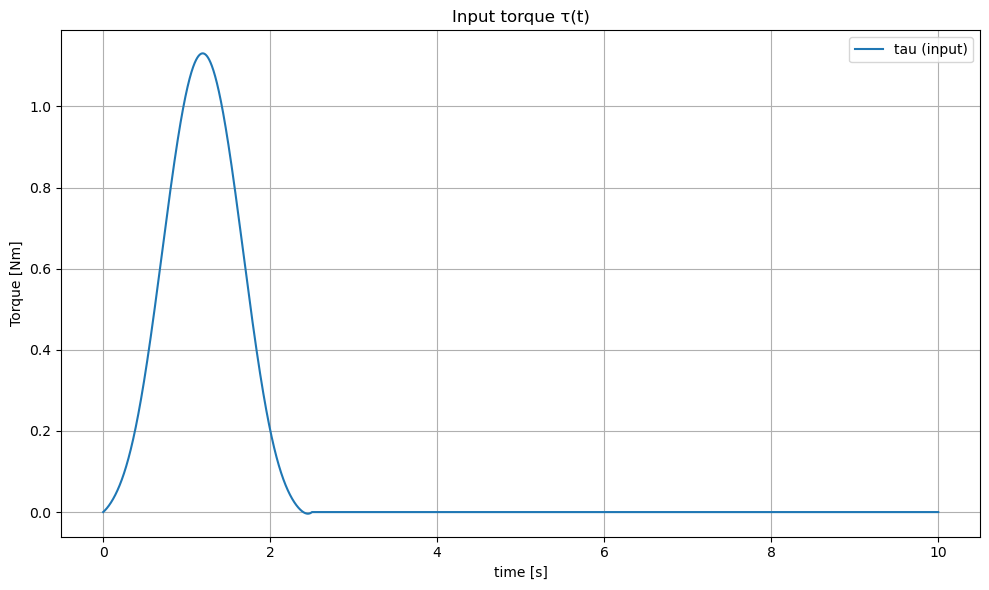

In [11]:
#plot u_ref
tau_sim = np.array([u_ref(t) for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, tau_sim, label="tau (input)")
plt.ylabel("Torque [Nm]")
plt.xlabel("time [s]")
plt.title("Input torque τ(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**3.11 Erweitern Sie Ihre Steuerung aus 3.9 um einen Zustandsregler zu einer 2-
Freiheitsgraderegelung. Gehen Sie davon aus, dass Ihnen der gesamte Zustand als 
Messung zur Verfügung steht. Testen Sie den Regler simulativ für das in 3.10
beschriebene Szenario unter Berücksichtigung der Haftreibungen.**

In [12]:
A, b = furuta_systems.get_linear_furuta(params_auslegung, operating_point)
eigs = np.linalg.eigvals(A)
omega0_scale = 1.0
omega0 = float(omega0_scale * np.max(np.abs(eigs)))
D = -0.5
D_down = 1.01 * D

s = sp.symbols('s')
regler_poly = (s-omega0*D)*(s-omega0*D_down)*(s**2 + 2*D*omega0*s + omega0**2)
regler_poly = sp.expand(regler_poly)
regler_poly = sp.collect(regler_poly, s)
regler_poly

s**4 + 0.0873340996458936*s**3 + 75.5097251134913*s**2 + 4010.03380009289*s + 23502.6457405659

In [13]:
a0_hat = regler_poly.subs(s, 0)
a1_hat = regler_poly.coeff(s)
a2_hat = regler_poly.coeff(s**2)
a3_hat = regler_poly.coeff(s**3)

a0, a1, a2, a3 = furuta_systems.get_a_coefficients_furuta(params_auslegung, operating_point)
A_RNF, Q = furuta_systems.get_RNF_furuta(params_auslegung, operating_point)

In [14]:
kT_RNF = np.array([[a0_hat - a0, a1_hat - a1, a2_hat - a2, a3_hat - a3]])
kT = kT_RNF @ Q
kT

array([[11.1411917910734, 1.38721519576904, 11.1554475452999,
        1.95563898215812]], dtype=object)

In [15]:
import scipy
imag = np.sqrt(1.0 - D**2)
k_res = scipy.signal.place_poles(A, b, (D*omega0, D_down*omega0, omega0*(D+1j*imag), omega0*(D-1j*imag)))
k = k_res.gain_matrix
kT

array([[11.14119179,  2.66291299, -7.20943667,  2.22440443]])

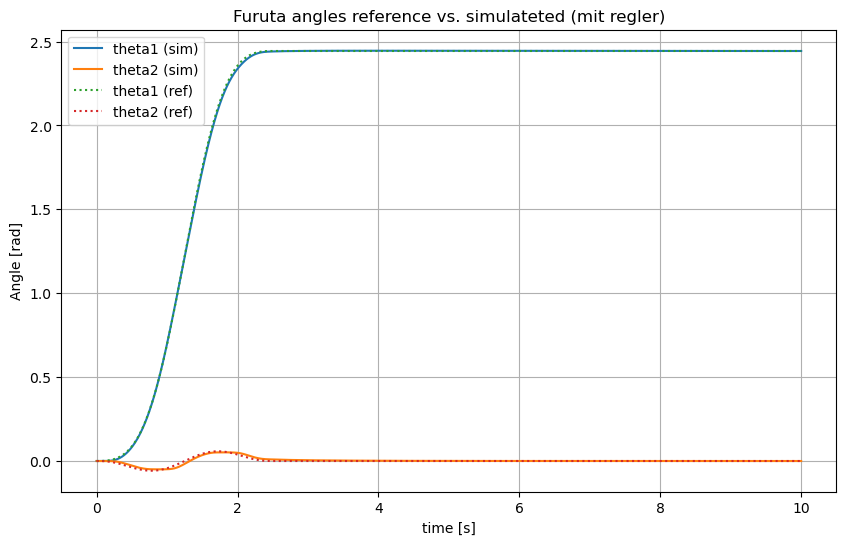

In [16]:
def simulation_system_2FHG(t, x):
    u = u_ref(t) -kT @ (x - x_ref(t))
    return non_linear_furuta_system(t, x, u)

sol = solve_ivp(
    simulation_system_2FHG,
    (float(t_sim[0]), float(t_sim[-1])),
    x0,
    t_eval=t_sim,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-3,
)

#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("Furuta angles reference vs. simulateted (mit regler)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

**a) Entwerfen Sie auf Basis des linearisierten Modells aus 3.9 einen reduzierten 
Beobachter.
b) Implementieren und integrieren Sie den Beobachter in Ihre Simulationsumgebung 
und den Regelkreis aus 3.11, um die nicht messbaren Winkelgeschwindigkeiten 
für den Regler damit zu bestimmen.
c) Vergleichen Sie die Ergebnisse mit denen aus 3.11.**

In [17]:
print(np.array2string(A, precision=3, suppress_small=True))

[[  0.      1.      0.      0.   ]
 [  0.    -17.516   1.075   0.   ]
 [  0.      0.      0.      1.   ]
 [  0.     16.969 -62.354  -0.026]]


In [18]:
print(np.array2string(b, precision=3, suppress_small=True))

[[  0.   ]
 [ 34.406]
 [  0.   ]
 [-33.331]]


In [19]:
A11 = np.array([[A[0][0], A[0][2]], [A[2][0], A[2][2]]])
A22 = np.array([[A[1][1], A[1][3]], [A[3][1], A[3][3]]])
A12 = np.array([[A[0][1], A[0][3]], [A[2][1], A[2][3]]])
A21 = np.array([[A[1][0], A[1][2]], [A[3][0], A[3][2]]])
b1 = np.array([[b[0][0]], [b[2][0]]])
b2 = np.array([[b[1][0]], [b[3][0]]])
b2

array([[ 34.40615006],
       [-33.33095788]])

In [20]:
from scipy.linalg import solve_continuous_are

Q = np.array([[50, 0], [0, 30]])
R = np.array([[1, 0], [0, 0.1]])

P = solve_continuous_are(A22.T, A12.T, Q, R)
l = (np.linalg.inv(R) * (A12.T @ P)).T


def reduced_observer(t, zeta, y, u):
    zeta_d = (A22 - l@A12)@zeta + ((A22 - l@A12)@l - A11@l + A21)@y + (b2 - l@b1) * u
    return zeta_d
l

array([[ 1.29607749,  0.        ],
       [ 0.        , 21.89110695]])

In [21]:
x0 = [0.0, 0.0, 0.0, 0.0]

(2, 1)

**2FHG mit reduziertem Beobachter, der noch nicht für die Regelung genutzt wird**

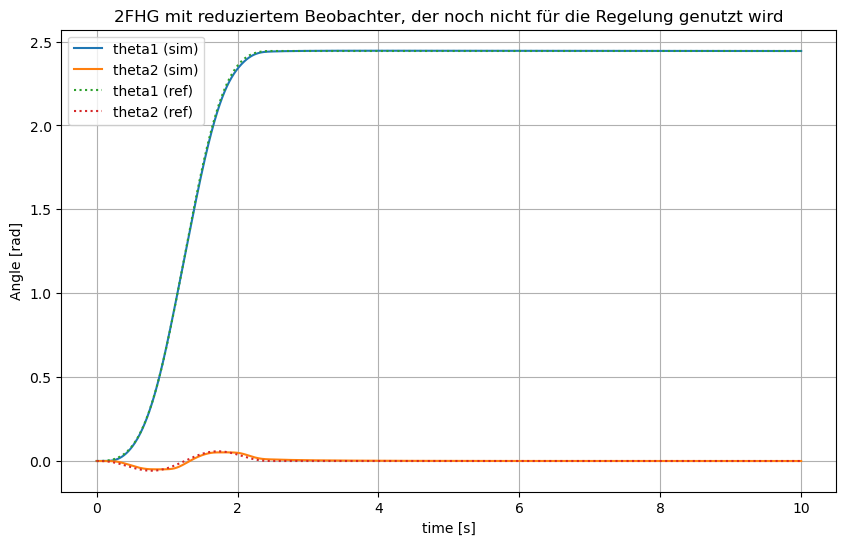

In [22]:
def simulation_system_2FHG_with_observer(t, s):
    x = s[:4]
    zeta = s[4:].reshape(2, 1)

    y = np.array([[x[0]], [x[2]]])
    u = u_ref(t) - kT @ (x - x_ref(t))

    x_dot = non_linear_furuta_system(t, x, u)
    zeta_dot = reduced_observer(t, zeta, y, u)

    return np.concatenate([x_dot, zeta_dot.flatten()])

s0 = np.concatenate([x0, np.zeros(2)])

sol = solve_ivp(
    simulation_system_2FHG_with_observer,
    (float(t_sim[0]), float(t_sim[-1])),
    s0,
    t_eval=t_sim,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-3,
)

#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("2FHG mit reduziertem Beobachter, der noch nicht für die Regelung genutzt wird")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

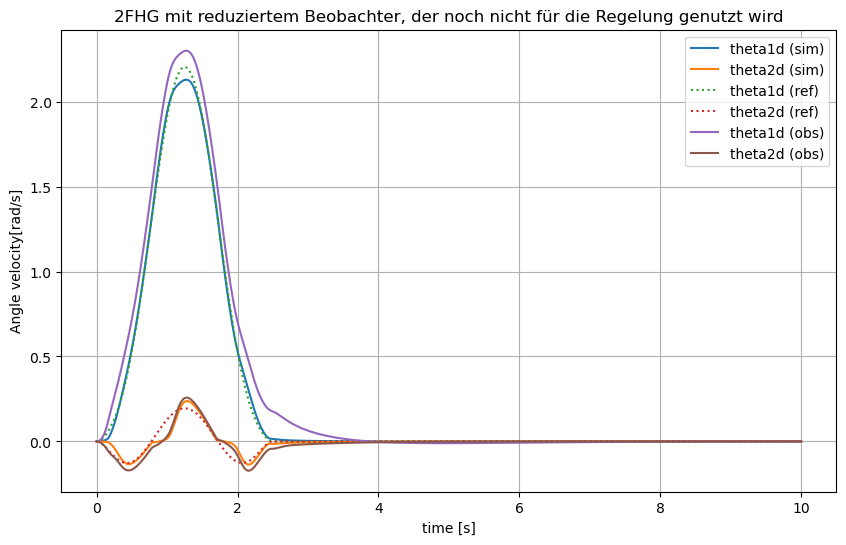

In [23]:
#plot sim angles
theta1d_sim = sol.y[1]
theta2d_sim = sol.y[3]

#plot x_ref
theta1d_ref = np.array([x_ref(t)[1] for t in t_sim])
theta2d_ref = np.array([x_ref(t)[3] for t in t_sim])

# sol.y shape: (6, N)
zeta_log = sol.y[4:6, :].T     # shape: (N, 2)
y_log   = sol.y[[0, 2], :].T  # shape: (N, 2)

# l shape: (2, 2)
x2_hat_log = zeta_log + (l @ y_log.T).T   # shape: (N, 2)

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1d_sim, label="theta1d (sim)")
plt.plot(t_sim, theta2d_sim, label="theta2d (sim)")
plt.plot(t_sim, theta1d_ref, label="theta1d (ref)", linestyle=':')
plt.plot(t_sim, theta2d_ref, label="theta2d (ref)", linestyle=':')

plt.plot(t_sim, x2_hat_log[:, 0], label="theta1d (obs)")
plt.plot(t_sim, x2_hat_log[:, 1], label="theta2d (obs)")


plt.title("2FHG mit reduziertem Beobachter, der noch nicht für die Regelung genutzt wird")
plt.ylabel("Angle velocity[rad/s]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

**2FHG mit reduziertem Beobachter (intigriert in die Regelung)**

In [24]:
def simulation_system_2FHG_with_observer(t, s):
    x = s[:4]
    zeta = s[4:].reshape(2, 1)
    y = np.array([[x[0]], [x[2]]])

    x2_hat = zeta + l@y
   
    x_obs = np.array([x[0], x2_hat[0, 0], x[2], x2_hat[1, 0]])
    
    u = u_ref(t) - kT @ (x_obs - x_ref(t))

    x_dot = non_linear_furuta_system(t, x, u)
    zeta_dot = reduced_observer(t, zeta, y, u)

    return np.concatenate([x_dot, zeta_dot.flatten()])

s0 = np.concatenate([x0, np.zeros(2)])

sol = solve_ivp(
    simulation_system_2FHG_with_observer,
    (float(t_sim[0]), float(t_sim[-1])),
    s0,
    t_eval=t_sim,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-3,
)

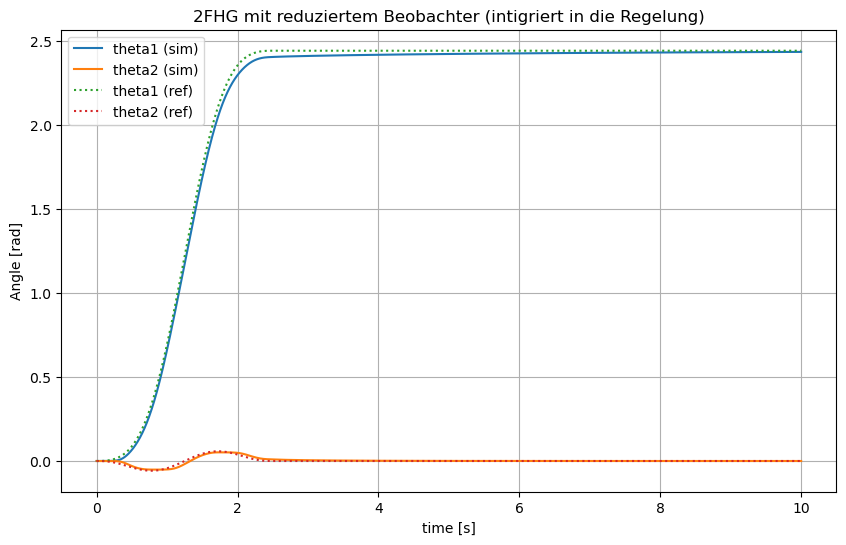

In [25]:
#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("2FHG mit reduziertem Beobachter (intigriert in die Regelung)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

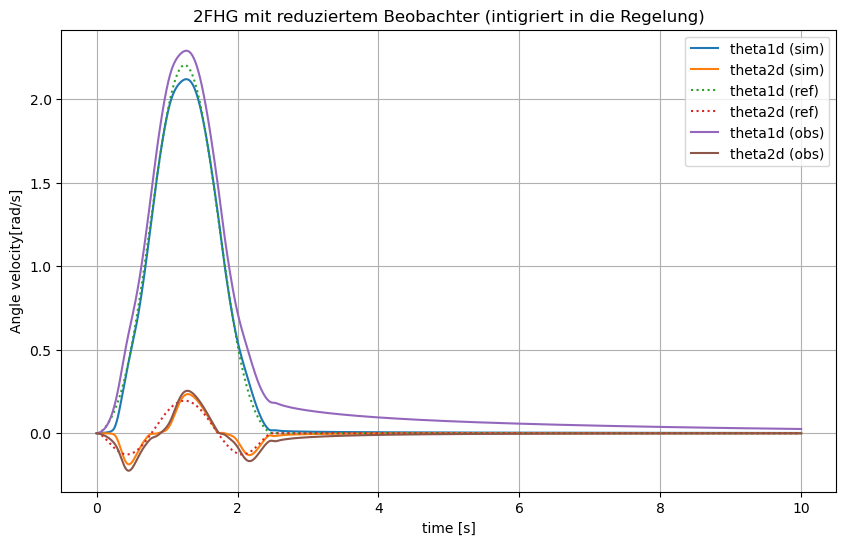

In [26]:
#plot sim angles
theta1d_sim = sol.y[1]
theta2d_sim = sol.y[3]

#plot x_ref
theta1d_ref = np.array([x_ref(t)[1] for t in t_sim])
theta2d_ref = np.array([x_ref(t)[3] for t in t_sim])

# sol.y shape: (6, N)
zeta_log = sol.y[4:6, :].T     # shape: (N, 2)
y_log   = sol.y[[0, 2], :].T  # shape: (N, 2)

# l shape: (2, 2)
x2_hat_log = zeta_log + (l @ y_log.T).T   # shape: (N, 2)

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1d_sim, label="theta1d (sim)")
plt.plot(t_sim, theta2d_sim, label="theta2d (sim)")
plt.plot(t_sim, theta1d_ref, label="theta1d (ref)", linestyle=':')
plt.plot(t_sim, theta2d_ref, label="theta2d (ref)", linestyle=':')

plt.plot(t_sim, x2_hat_log[:, 0], label="theta1d (obs)")
plt.plot(t_sim, x2_hat_log[:, 1], label="theta2d (obs)")


plt.title("2FHG mit reduziertem Beobachter (intigriert in die Regelung)")
plt.ylabel("Angle velocity[rad/s]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()

**Aufbauend auf den vorangegangenen Ergebnissen, soll nun die Überführung in der 
instabilen Ruhelage theta2 = 180° untersucht werden.**

**3.13 Verwenden Sie die in 3.11 entworfene 2-Freiheitsgraderegelung, um das System von der 
instabilen Ruhelage x = (0°, 0°/s, 180°, 0°/s) auf x = (140°, 0°/s, 180°, 0°/s)
für t1 = 0 s und t2 = 2.5 s zu überführen. Geben Sie neben der Transformationsmatrix 
auch die Systemmatrix und den Eingangsvektor an. Gehen Sie davon aus, dass Ihnen 
der gesamte Zustand als Messung zur Verfügung steht. Wählen Sie als Startzustand 
die instabile Ruhelage x = (0°, 0°/s, 180°, 0°/s) und Berücksichtigung Sie die Haftreibungen.**

In [27]:
import furuta_systems
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import furuta_params
import furuta_trajectory_gen

params_auslegung = furuta_params.FurutaParams()
params_auslegung.mu_H1 = 0.0
params_auslegung.mu_H2 = 0.0
params_sim = furuta_params.FurutaParams()
params_sim.mu_H1 = 0.0
params_sim.mu_H2 = 0.0

t_sim = np.linspace(0.0, 10.0, 10000)

theta2_op_unstable = 180.0/360.0 * 2 * np.pi
operating_point_unstable = (0.0, 0.0, theta2_op_unstable, 0.0, 0.0)

non_linear_furuta_system = furuta_systems.get_non_linear_furuta_system(params_sim)
A, b = furuta_systems.get_linear_furuta(params_auslegung, operating_point_unstable)
b

array([[ 0.        ],
       [34.40615006],
       [ 0.        ],
       [33.33095788]])

In [28]:
Q = np.array([ [10, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1] ])
R = np.array([[5]])

from scipy.linalg import solve_continuous_are
P = solve_continuous_are(A, b, Q, R)
kT = np.linalg.inv(R) * (b.T @ P)
kT

array([[-1.41421356, -1.61617793, 19.02097593,  2.46160348]])

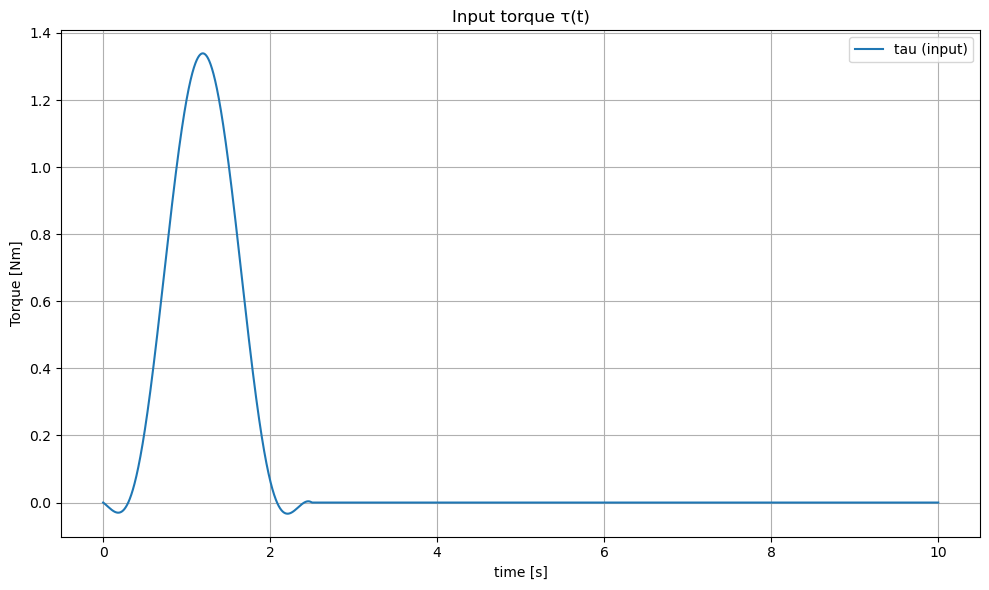

In [29]:
cT = np.array([[1, 0, 0, 0]])
b0, b1, b2, b2 = furuta_systems.get_b_coefficients_furuta(cT, params_auslegung, operating_point_unstable)
y0 = 0.0
yT = (140.0/360.0) * 2 * np.pi
eta_t0 = y0/b0
eta_t1 = yT/b0
t0 = 0
t1 = 2.5

u_ref, x_ref = furuta_trajectory_gen.generate_trajectorys(eta_t0, eta_t1, t0, t1, params_auslegung, operating_point_unstable)

#plot u_ref
tau_sim = np.array([u_ref(t) for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, tau_sim, label="tau (input)")
plt.ylabel("Torque [Nm]")
plt.xlabel("time [s]")
plt.title("Input torque τ(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def simulation_system_2FHG_unstable(t, x):
    u = u_ref(t) -kT @ (x - x_ref(t))
    if np.abs(u) > 4: 
        u = 4*np.sign(u)
    return non_linear_furuta_system(t, x, u)

x0 = [0.0, 0.0, theta2_op_unstable, 0.0]


sol = solve_ivp(
    simulation_system_2FHG_unstable,
    (float(t_sim[0]), float(t_sim[-1])),
    x0,
    t_eval=t_sim,
    rtol=1e-2,
    atol=1e-2,
    max_step=1e-3,
)

#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("Furuta angles reference vs. simulateted (mit regler)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()